In [20]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download(
    "sanikatiwarekar/deep-fake-detection-dfd-entire-original-dataset"
)

print("Dataset Path:", path)

Dataset Path: /kaggle/input/datasets/sanikatiwarekar/deep-fake-detection-dfd-entire-original-dataset


In [21]:
import os
import cv2
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# Performance optimization
tf.keras.mixed_precision.set_global_policy("mixed_float16")
tf.config.optimizer.set_jit(True)

In [22]:
BASE_PATH = path

REAL_PATH = os.path.join(BASE_PATH, "DFD_original sequences")
FAKE_PATH = os.path.join(BASE_PATH, "DFD_manipulated_sequences", "DFD_manipulated_sequences")

assert os.path.exists(REAL_PATH)
assert os.path.exists(FAKE_PATH)

print("✅ Paths verified")

✅ Paths verified


In [23]:
IMG_SIZE = 128
FRAME_COUNT = 10
BATCH_SIZE = 32
CLASS_NAMES = ["Real", "Fake"]

In [24]:
def extract_frames(video_path):

    cap = cv2.VideoCapture(video_path)
    frames = []

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total // FRAME_COUNT, 1)

    for i in range(FRAME_COUNT):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = preprocess_input(frame)
        frames.append(frame)

    cap.release()
    return np.array(frames)

In [25]:
real_videos = sorted(os.listdir(REAL_PATH))
fake_videos = sorted(os.listdir(FAKE_PATH))

fake_videos = fake_videos[:len(real_videos)]

real_train, real_test = train_test_split(real_videos, test_size=0.3, random_state=42)
fake_train, fake_test = train_test_split(fake_videos, test_size=0.3, random_state=42)

print("Train:", len(real_train), len(fake_train))
print("Test:", len(real_test), len(fake_test))

Train: 254 254
Test: 110 110


In [26]:
def load_videos(video_list, label, base_path):

    X, y, ids = [], [], []

    for vid in tqdm(video_list):
        frames = extract_frames(os.path.join(base_path, vid))
        if len(frames) != FRAME_COUNT:
            continue

        for f in frames:
            X.append(f)
            y.append(label)
            ids.append(vid)

    return np.array(X), np.array(y), np.array(ids)

In [27]:
X_real, y_real, _ = load_videos(real_train, 0, REAL_PATH)
X_fake, y_fake, _ = load_videos(fake_train, 1, FAKE_PATH)

X_train = np.concatenate([X_real, X_fake])
y_train = np.concatenate([y_real, y_fake])

100%|██████████| 254/254 [15:33<00:00,  3.68s/it]


In [28]:
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1)
])

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(5000)
train_ds = train_ds.map(lambda x,y:(augment(x),y), num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [30]:
def build_model(drop=0.3, l2v=0.01):

    base = MobileNetV2(weights="imagenet",
                       include_top=False,
                       input_shape=(IMG_SIZE,IMG_SIZE,3))

    base.trainable = True

    model = Sequential([
        base,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dropout(drop),
        Dense(256, activation="relu", kernel_regularizer=l2(l2v)),
        Dropout(drop),
        Dense(1, activation="sigmoid", dtype=tf.float32)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [31]:
models = {
    "V1": build_model(0.3,0.01),
    "V2": build_model(0.2,0.0),
    "V3": build_model(0.5,0.02)
}

early = EarlyStopping(patience=5, restore_best_weights=True)

histories = {}

for name,m in models.items():
    print(name)
    h = m.fit(train_ds, epochs=20, callbacks=[early])
    histories[name]=m

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
V1
Epoch 1/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 257s 765ms/step - accuracy: 0.5222 - loss: 4.9974
Epoch 2/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.5857 - loss: 4.3360
Epoch 3/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.6246 - loss: 3.8035
Epoch 4/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 79ms/step - accuracy: 0.6502 - loss: 3.3894
Epoch 5/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.6643 - loss: 3.0278
Epoch 6/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.6764 - loss: 2.7257
Epoch 7/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.6763 - loss: 2.5025
Epoch 8/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.7003 - loss: 2.2364
Epoch 9/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.6983 - loss: 2.0585
Epoch 10/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.6954 - loss: 1.8880
Epoch 11/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy

In [32]:
Xr, yr, idr = load_videos(real_test,0,REAL_PATH)
Xf, yf, idf = load_videos(fake_test,1,FAKE_PATH)

X_test = np.concatenate([Xr,Xf])
y_test = np.concatenate([yr,yf])
vid_ids = np.concatenate([idr,idf])

100%|██████████| 110/110 [06:55<00:00,  3.77s/it]


In [33]:
results=[]

for name,model in histories.items():

    probs = model.predict(X_test).flatten()
    preds = (probs>0.5).astype(int)

    frame_acc = accuracy_score(y_test,preds)

    video_preds=defaultdict(list)
    labels={}

    for i,v in enumerate(vid_ids):
        video_preds[v].append(probs[i])
        labels[v]=y_test[i]

    vtrue=[]
    vpred=[]
    vprobs=[]

    for v,p in video_preds.items():
        avg=np.mean(p)
        vpred.append(int(avg>0.5))
        vtrue.append(labels[v])
        vprobs.append(avg)

    video_acc=accuracy_score(vtrue,vpred)

    fpr,tpr,_=roc_curve(y_test,probs)
    roc_auc=auc(fpr,tpr)

    results.append([name,frame_acc,video_acc,roc_auc])

df=pd.DataFrame(results,columns=["Model","FrameAcc","VideoAcc","ROC"])
df.sort_values("VideoAcc",ascending=False)

69/69 ━━━━━━━━━━━━━━━━━━━━ 40s 421ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 26s 211ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 25s 193ms/step


,Model,FrameAcc,VideoAcc,ROC
2,V3,0.887727,0.904545,0.928226
1,V2,0.887273,0.895455,0.930396
0,V1,0.870000,0.890909,0.910996


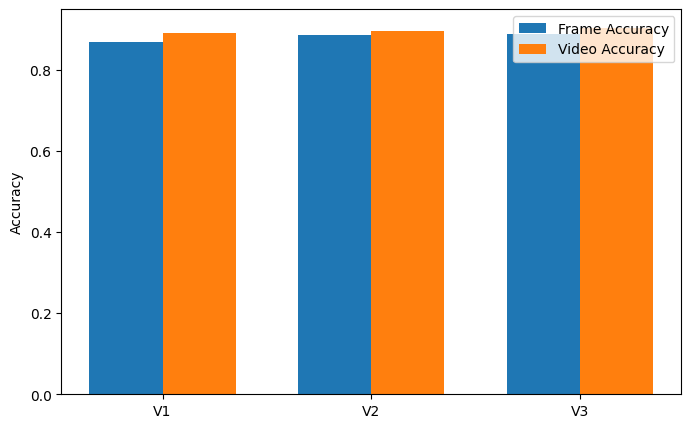

In [34]:
results_df = pd.DataFrame(results, columns=[
    "Model",
    "Frame Accuracy",
    "Video Accuracy",
    "ROC AUC"
])

plt.figure(figsize=(8,5))
x = np.arange(len(results_df["Model"]))
bar_width = 0.35

plt.bar(x - bar_width/2, results_df["Frame Accuracy"], width=bar_width, label="Frame Accuracy")
plt.bar(x + bar_width/2, results_df["Video Accuracy"], width=bar_width, label="Video Accuracy")

plt.xticks(x, results_df["Model"])
plt.ylabel("Accuracy")
plt.legend()
plt.show()